# Chartistry: Milestone 1 - Trending Youtube Videos

### Imports and Data Loading

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [2]:
# Load datasets
data = "../data/"
df_us = pd.read_csv(data + "USvideos.csv")
df_de = pd.read_csv(data + "DEvideos.csv")
df_fr = pd.read_csv(data + "FRvideos.csv")
df_gb = pd.read_csv(data + "GBvideos.csv")
df_in = pd.read_csv(data + "INvideos.csv")
df_jp = pd.read_csv(
    data + "JPvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)
df_kr = pd.read_csv(
    data + "KRvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)
df_mx = pd.read_csv(
    data + "MXvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)
df_ru = pd.read_csv(
    data + "RUvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)

Russia, Mexico, South Korea, and Japan contain unknown / undecodable characters. The encoding characters have been replaced by "�". Let's check how many rows are affected for each datasets

In [3]:
def count_corrupted_rows(df):
    return df.apply(
        lambda row: row.astype(str).str.contains("�").any(),
        axis=1
    ).sum()

In [4]:
print("JP:", count_corrupted_rows(df_jp))
print("KR:", count_corrupted_rows(df_kr))
print("MX:", count_corrupted_rows(df_mx))
print("RU:", count_corrupted_rows(df_ru))

JP: 10
KR: 66
MX: 3
RU: 44


### Pre-processing

Let's add the country column to the dataframes and merge them all into a single dataframe

In [5]:
# Add a country column to each dataset
df_us["country"] = "US"
df_de["country"] = "DE"
df_fr["country"] = "FR"
df_gb["country"] = "GB"
df_in["country"] = "IN"
df_jp["country"] = "JP"
df_kr["country"] = "KR"
df_mx["country"] = "MX"
df_ru["country"] = "RU"

In [6]:
# Combine all datasets into one
df = pd.concat(
    [df_us, df_de, df_fr, df_gb, df_in, df_jp, df_kr, df_mx, df_ru],
    ignore_index=True
)

# Quick check
df.shape

(335061, 17)

We inspect the data and check for missing values

In [7]:
# First rows
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,US
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",US
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,US
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,US
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,US


In [8]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335061 entries, 0 to 335060
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   video_id                335061 non-null  object
 1   trending_date           335061 non-null  object
 2   title                   335061 non-null  object
 3   channel_title           335061 non-null  object
 4   category_id             335061 non-null  int64 
 5   publish_time            335061 non-null  object
 6   tags                    335061 non-null  object
 7   views                   335061 non-null  int64 
 8   likes                   335061 non-null  int64 
 9   dislikes                335061 non-null  int64 
 10  comment_count           335061 non-null  int64 
 11  thumbnail_link          335061 non-null  object
 12  comments_disabled       335061 non-null  bool  
 13  ratings_disabled        335061 non-null  bool  
 14  video_error_or_removed  335061 non-n

In [9]:
# Check missing values
df.isnull().sum()

video_id                      0
trending_date                 0
title                         0
channel_title                 0
category_id                   0
publish_time                  0
tags                          0
views                         0
likes                         0
dislikes                      0
comment_count                 0
thumbnail_link                0
comments_disabled             0
ratings_disabled              0
video_error_or_removed        0
description               18182
country                       0
dtype: int64

We can see that only the description column has missing values. Let's fill them with a "No description" tag, and create a new column to tell whether a video has a description or not, since it can be usefull for future analysis.

In [10]:
# Drop duplicates
df = df.drop_duplicates()

# Handle missing descriptions
df["description"] = df["description"].fillna("No description")
df["has_description"] = df["description"] != "No description"

We also convert dates to datetime, and extract / store date attributes in different columns.

In [11]:
# Convert trending_date
df["trending_date"] = df["trending_date"].astype(str).str.strip()
df["trending_date"] = pd.to_datetime(
    df["trending_date"],
    format="%y.%d.%m",
    errors="coerce"
)

# Convert publish_time
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")

# Remove timezone info from publish_time so it matches trending_date
df["publish_time"] = df["publish_time"].dt.tz_localize(None)

# Extract temporal features from publish_time
df["publish_hour"] = df["publish_time"].dt.hour
df["publish_day"] = df["publish_time"].dt.day_name()
# Days between publication and trending
df["days_to_trending"] = (df["trending_date"] - df["publish_time"]).dt.days

df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country,has_description,publish_hour,publish_day,days_to_trending
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,US,True,17,Monday,0
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",US,True,7,Monday,0
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,US,True,19,Sunday,1
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,US,True,11,Monday,0
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,US,True,18,Sunday,1


### Exploratory Data Analysis

We first check basic statistics

In [12]:
# Summary statistics
df.describe()

,trending_date,category_id,publish_time,views,likes,dislikes,comment_count,publish_hour,days_to_trending
count,322491,322491.000000,322491,3.224910e+05,3.224910e+05,3.224910e+05,3.224910e+05,322491.000000,322491.000000
mean,2018-02-27 07:51:02.295692032,20.146637,2018-02-19 15:23:06.441888256,1.368050e+06,3.826511e+04,2.175093e+03,4.209386e+03,12.721778,7.232543
min,2017-11-14 00:00:00,1.000000,2006-07-23 08:24:11,1.170000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.000000
25%,2018-01-04 00:00:00,17.000000,2018-01-01 17:48:54.500000,4.039500e+04,5.930000e+02,3.600000e+01,9.400000e+01,8.000000,0.000000
50%,2018-02-27 00:00:00,23.000000,2018-02-23 11:24:08,1.550060e+05,3.076000e+03,1.640000e+02,4.490000e+02,14.000000,0.000000
75%,2018-04-23 00:00:00,24.000000,2018-04-19 23:00:03,6.013120e+05,1.629300e+04,7.240000e+02,1.819000e+03,17.000000,2.000000
max,2018-06-14 00:00:00,44.000000,2018-06-14 03:40:05,4.245389e+08,5.613827e+06,1.944971e+06,1.626501e+06,23.000000,4214.000000
std,NaN,7.184454,NaN,7.538297e+06,1.698951e+05,2.328164e+04,2.587284e+04,6.181869,102.919042


In [13]:
# Statistics per country
df.groupby("country")[["views", "likes", "comment_count"]].mean()

,views,likes,comment_count
country,,,
DE,6.034553e+05,21875.502889,2785.856513
FR,4.199219e+05,17388.863815,1832.452706
GB,5.911293e+06,134467.288063,13080.388876
IN,9.963425e+05,25587.621052,2524.777660
JP,2.537013e+05,8033.437492,1143.866900
KR,4.233832e+05,12059.058975,1971.372919
MX,3.401750e+05,15726.871021,2015.972526
RU,2.388132e+05,12302.939400,1749.275281
US,2.360678e+06,74271.734285,8448.567150


We check the distribution of views

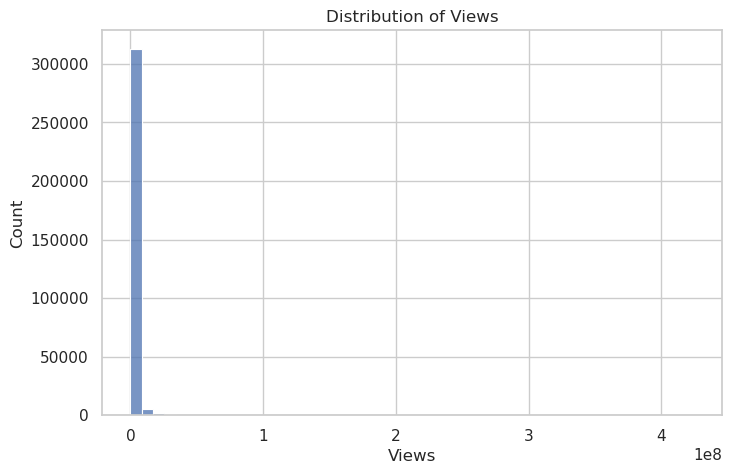

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df["views"], bins=50)
plt.title("Distribution of Views")
plt.xlabel("Views")
plt.ylabel("Count")
plt.show()

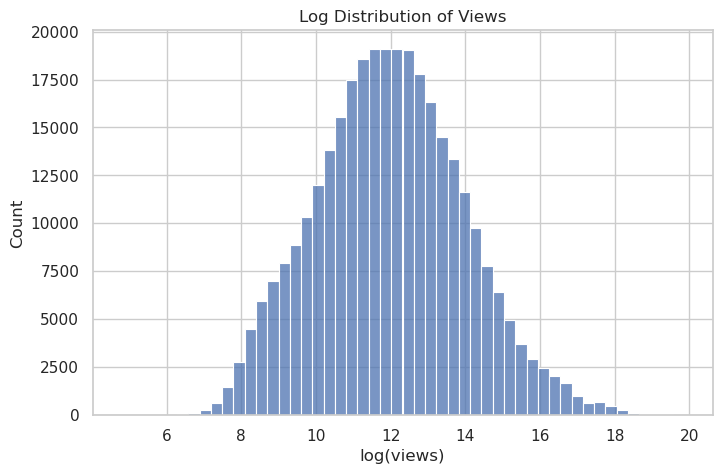

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df["views"]), bins=50)
plt.title("Log Distribution of Views")
plt.xlabel("log(views)")
plt.savefig("images/views_log.png", dpi=300, bbox_inches="tight")
plt.show()

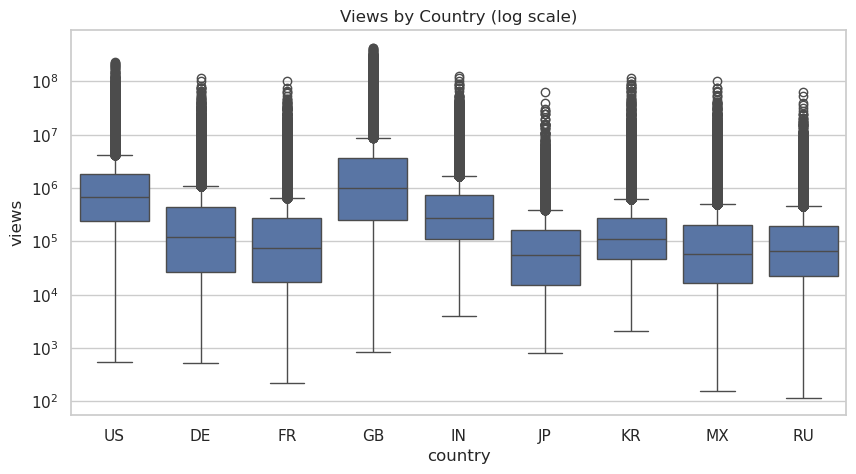

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="country", y="views", data=df)
plt.yscale("log")
plt.title("Views by Country (log scale)")
plt.savefig("images/views_log_country.png", dpi=300, bbox_inches="tight")
plt.show()

We do a small correlation analysis

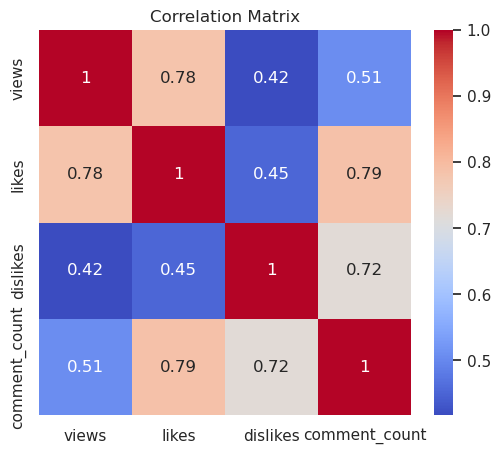

In [17]:
# Select numeric columns
num_cols = ["views", "likes", "dislikes", "comment_count"]

corr = df[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("images/correlation.png", dpi=300, bbox_inches="tight")
plt.show()

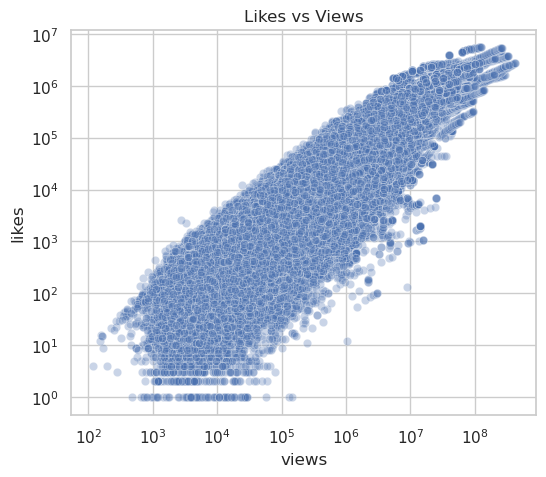

In [18]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x="views", y="likes", data=df, alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.title("Likes vs Views")
plt.savefig("images/likes_views.png", dpi=300, bbox_inches="tight")
plt.show()

We can see that likes and views are indeed very correlated

We now check when do videos trend most

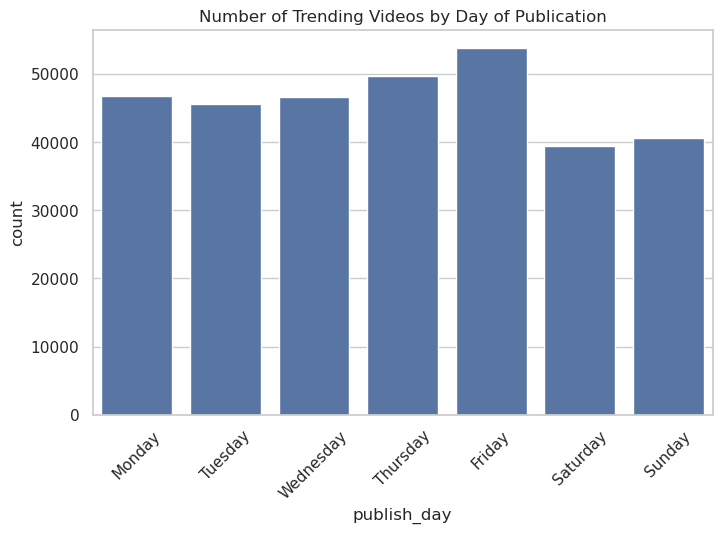

In [19]:
plt.figure(figsize=(8, 5))

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.countplot(
    data=df,
    x="publish_day",
    order=day_order
)

plt.title("Number of Trending Videos by Day of Publication")
plt.xticks(rotation=45)
plt.savefig("images/week_day.png", dpi=300, bbox_inches="tight")
plt.show()

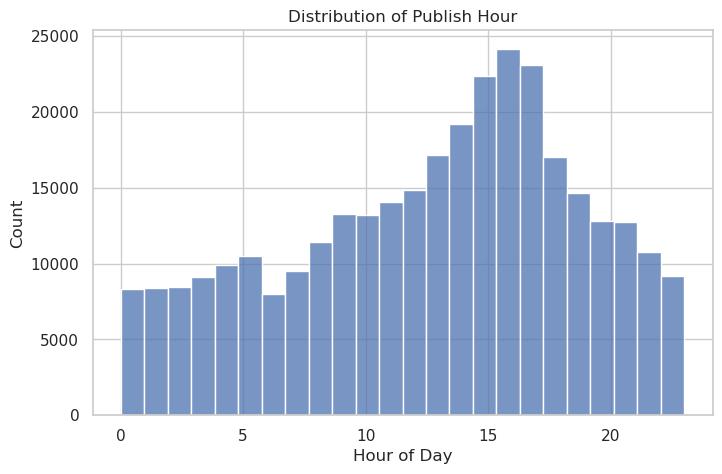

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(df["publish_hour"], bins=24)

plt.title("Distribution of Publish Hour")
plt.xlabel("Hour of Day")
plt.savefig("images/hour_day.png", dpi=300, bbox_inches="tight")
plt.show()

We can see that trending videos are less often published on the weekend. And also that most trending videos are published around 4 pm.

Let's check how many days it takes for trending in general

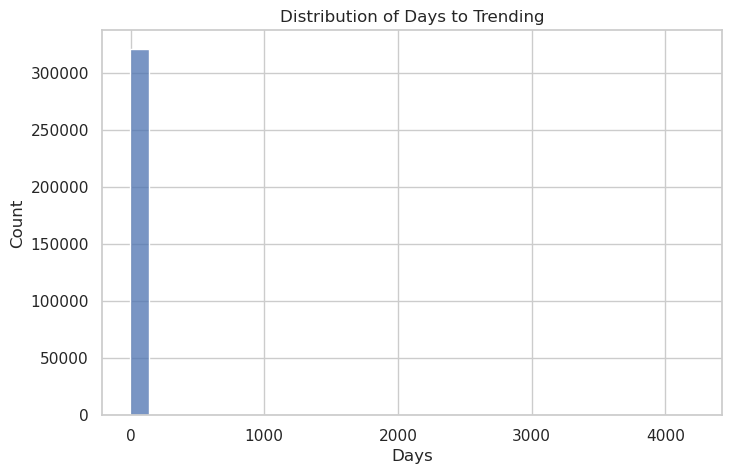

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(df["days_to_trending"], bins=30)

plt.title("Distribution of Days to Trending")
plt.xlabel("Days")
plt.show()

In [22]:
df["days_to_trending"].describe()

count    322491.000000
mean          7.232543
std         102.919042
min          -1.000000
25%           0.000000
50%           0.000000
75%           2.000000
max        4214.000000
Name: days_to_trending, dtype: float64

The mean is around 7, but the distribution is heavily skewed, most of videos trend the first days